# Objective 1
Explains and tests the baseline measurement.

In [13]:
import torch
import torchaudio
import torchaudio.transforms as T
import librosa
import librosa.display
import numpy as np
from pathlib import Path

# --- COLAB SETUP ---
data_dir = Path("/content")
target_path = data_dir / "target_sample.wav"
user_path = data_dir / "user_sample.wav"

# Load the Wav2Vec2 model globally
print("Loading Wav2Vec2 model (this may take a moment the first time)...")
bundle = torchaudio.pipelines.WAV2VEC2_BASE
w2v2_model = bundle.get_model()
w2v2_model.eval()

# ===========================================================================
# PI1 (basic): Successfully load audio files into PyTorch tensors using TorchAudio.
# ===========================================================================
def load_audio(file_path, target_sr=16000):
    waveform, sr = torchaudio.load(file_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != target_sr:
        resampler = T.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)
        sr = target_sr
    return waveform.squeeze(), sr

# ===========================================================================
# PI2 (basic): Extract pitch frequency.
# ===========================================================================
def get_pitch_track(waveform, sr):
    y = waveform.numpy()
    f0, _, _ = librosa.pyin(y, fmin=60, fmax=500, sr=sr)
    return f0

# ===========================================================================
# PI3 & PI4 (expected): DTW alignment and MSE scoring for basic pitch.
# ===========================================================================
def align_and_score_pitch(pitch_target, pitch_user):
    p_target_clean = np.nan_to_num(pitch_target)
    p_user_clean = np.nan_to_num(pitch_user)

    # Euclidean distance is fine for 1D frequency values
    _, warp_path = librosa.sequence.dtw(X=p_target_clean, Y=p_user_clean, metric='euclidean')

    aligned_target = pitch_target[warp_path[:, 0]]
    aligned_user = pitch_user[warp_path[:, 1]]
    mse = np.nanmean((aligned_target - aligned_user) ** 2)
    return mse

# ===========================================================================
# PI5 (advanced): Integrate Wav2Vec2 to improve alignment for better scoring.
# ===========================================================================
def extract_wav2vec2_features(waveform):
    """Passes audio through Wav2Vec2 to get deep acoustic embeddings."""
    # Model expects shape (batch, time)
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    with torch.no_grad(): # Disable gradient calculation for faster inference
        features, _ = w2v2_model(waveform)

    # features shape: (batch, frames, hidden_dim).
    features = features.squeeze(0).numpy()

    return features.T

def align_and_score_features(feat_target, feat_user):
    """Aligns high-dimensional feature matrices and calculates MSE."""
    # Cosine distance for high-dimensional embeddings
    _, warp_path = librosa.sequence.dtw(X=feat_target, Y=feat_user, metric='cosine')

    aligned_target = feat_target[:, warp_path[:, 0]]
    aligned_user = feat_user[:, warp_path[:, 1]]

    # Calculate MSE across all embedded dimensions
    mse = np.mean((aligned_target - aligned_user) ** 2)
    return mse


# --- RUN THE FULL PIPELINE ---
if __name__ == "__main__":
    if not target_path.exists() or not user_path.exists():
        print("⚠️ Error: Please upload 'target_sample.wav' and 'user_sample.wav' to Colab first!")
    else:
        print("\n1. Loading audio files...")
        wave_target, sr_target = load_audio(target_path)
        wave_user, sr_user = load_audio(user_path)

        print("2. Extracting raw pitch (f0)...")
        pitch_target = get_pitch_track(wave_target, sr_target)
        pitch_user = get_pitch_track(wave_user, sr_user)

        print("3. Extracting Wav2Vec2 deep features...")
        feat_target = extract_wav2vec2_features(wave_target)
        feat_user = extract_wav2vec2_features(wave_user)

        print("4. Running alignments and calculating scores...")
        basic_score = align_and_score_pitch(pitch_target, pitch_user)
        advanced_score = align_and_score_features(feat_target, feat_user)

        print("\n" + "="*50)
        print(f"BASIC PITCH SCORE (MSE):    {basic_score:.2f}")
        print(f"ADVANCED W2V2 SCORE (MSE):  {advanced_score:.4f}")
        print("="*50)

Loading Wav2Vec2 model (this may take a moment the first time)...

1. Loading audio files...
2. Extracting raw pitch (f0)...
3. Extracting Wav2Vec2 deep features...
4. Running alignments and calculating scores...

BASIC PITCH SCORE (MSE):    2973.59
ADVANCED W2V2 SCORE (MSE):  0.0433


# Objective 2
Explains and tests the correction on a single file

Starting Objective 2: Vocal Correction and Evaluation Pipeline...

--- PI1: Audio Playback ---
Target Voice:


Original Voice:



--- PI2: Mel-Spectrogram Comparison ---


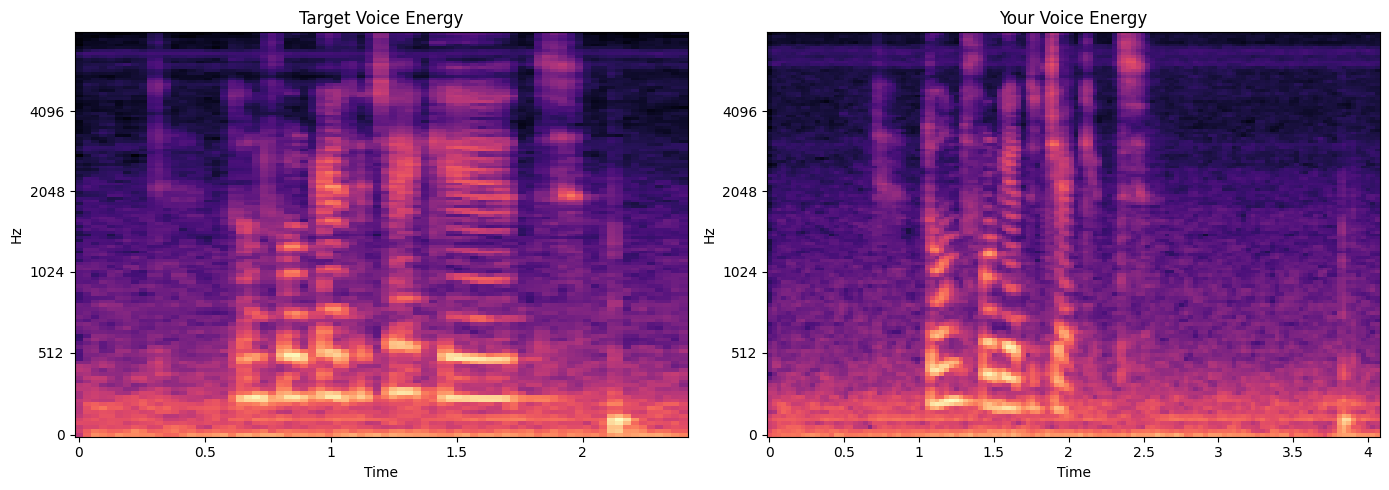


--- PI3: Mathematical Pitch Correction ---
Target Median Pitch: 252.81 Hz
Your Median Pitch:   190.49 Hz
Applying a shift of 4.90 semitones...

--- PI5: High-Quality Phase Vocoder Processing ---
Listen to your mathematically CORRECTED voice:



--- PI4: Final Mimicry Score ---
Re-evaluating alignment with the newly corrected audio...
FINAL MIMICRY SCORE (MSE): 1219.28


In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd
import soundfile as sf

print("Starting Objective 2: Vocal Correction and Evaluation Pipeline...\n")

# ===========================================================================
# PI1 (basic): Implement in-notebook audio playback
# ===========================================================================
print("--- PI1: Audio Playback ---")
print("Target Voice:")
display(ipd.Audio(data=wave_target.numpy(), rate=sr_target))

print("Original Voice:")
display(ipd.Audio(data=wave_user.numpy(), rate=sr_user))

# ===========================================================================
# PI2 (basic): Display side-by-side Mel-spectrograms
# ===========================================================================
print("\n--- PI2: Mel-Spectrogram Comparison ---")
def plot_mel_spectrograms(y_targ, sr_targ, y_usr, sr_usr):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    # Target Spectrogram
    S_targ = librosa.feature.melspectrogram(y=y_targ.numpy(), sr=sr_targ, n_mels=128)
    S_targ_dB = librosa.power_to_db(S_targ, ref=np.max)
    librosa.display.specshow(S_targ_dB, x_axis='time', y_axis='mel', sr=sr_targ, ax=ax[0])
    ax[0].set_title('Target Voice Energy')

    # User Spectrogram
    S_usr = librosa.feature.melspectrogram(y=y_usr.numpy(), sr=sr_usr, n_mels=128)
    S_usr_dB = librosa.power_to_db(S_usr, ref=np.max)
    librosa.display.specshow(S_usr_dB, x_axis='time', y_axis='mel', sr=sr_usr, ax=ax[1])
    ax[1].set_title('Your Voice Energy')

    plt.tight_layout()
    plt.show()

plot_mel_spectrograms(wave_target, sr_target, wave_user, sr_user)

# ===========================================================================
# PI3 (expected): Build a pitch-shifting algorithm
# ===========================================================================
print("\n--- PI3: Mathematical Pitch Correction ---")
# Find the median pitch for both voices
median_target = np.nanmedian(pitch_target[pitch_target > 0])
median_user = np.nanmedian(pitch_user[pitch_user > 0])

# Calculate the exact shift required in semitones
semitone_shift = 12 * np.log2(median_target / median_user)
print(f"Target Median Pitch: {median_target:.2f} Hz")
print(f"Your Median Pitch:   {median_user:.2f} Hz")
print(f"Applying a shift of {semitone_shift:.2f} semitones...")

# ===========================================================================
# PI5 (advanced): Apply high-quality signal processing
# ===========================================================================
print("\n--- PI5: High-Quality Phase Vocoder Processing ---")
y_user_np = wave_user.numpy()
y_corrected = librosa.effects.pitch_shift(
    y=y_user_np,
    sr=sr_user,
    n_steps=semitone_shift,
    res_type='soxr_hq'
)

# Save and display the fixed audio
corrected_path = "corrected_user.wav"
sf.write(corrected_path, y_corrected, sr_user)
print("Listen to your mathematically CORRECTED voice:")
display(ipd.Audio(data=y_corrected, rate=sr_user))

# ===========================================================================
# PI4 (expected): Calculate a final Mimicry Score (MSE)
# ===========================================================================
print("\n--- PI4: Final Mimicry Score ---")
print("Re-evaluating alignment with the newly corrected audio...")

# Re-extract the pitch from the newly shifted audio
pitch_corrected, _, _ = librosa.pyin(y_corrected, fmin=60, fmax=500, sr=sr_user)

# Clean the data for DTW math
p_target_clean = np.nan_to_num(pitch_target)
p_corrected_clean = np.nan_to_num(pitch_corrected)

# Re-run Dynamic Time Warping to check alignment
_, warp_path_final = librosa.sequence.dtw(X=p_target_clean, Y=p_corrected_clean, metric='euclidean')

# Calculate the new Mean Squared Error
aligned_target = pitch_target[warp_path_final[:, 0]]
aligned_corrected = pitch_corrected[warp_path_final[:, 1]]
final_mse = np.nanmean((aligned_target - aligned_corrected) ** 2)

print("="*40)
print(f"FINAL MIMICRY SCORE (MSE): {final_mse:.2f}")
print("="*40)

# Objective 2 PSOLA vs. Baseline

Natural corrected voice

In [4]:
!pip install praat-parselmouth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 85.2 MB/s eta 0:00:00


Starting Objective 2: Vocal Correction and Evaluation Pipeline (PSOLA Upgraded)...

--- PI1: Audio Playback ---
Target Voice:


Your Original Voice:



--- PI2: Mel-Spectrogram Comparison ---


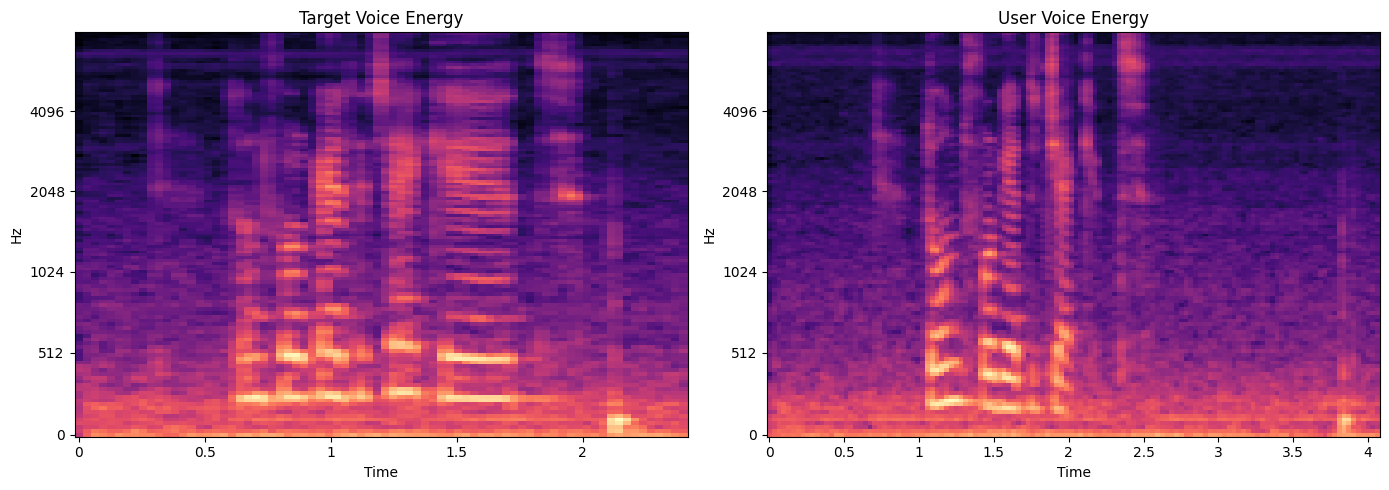


--- PI3: Mathematical Pitch Correction ---
Target Median Pitch: 252.81 Hz
User Median Pitch:   190.49 Hz
Calculated Shift:    4.90 semitones...

--- PI5: High-Quality PSOLA Pitch Correction ---
Applying formant-preserving pitch shift to maintain natural human timbre...
Listen to user MODIFIED voice:



--- PI4: Final Mimicry Score ---
Re-evaluating alignment with the newly corrected audio...
🎯 FINAL MIMICRY SCORE (MSE): 1562.83


In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd
import soundfile as sf
import parselmouth
from parselmouth.praat import call

print("Starting Objective 2: Vocal Correction and Evaluation Pipeline (PSOLA Upgraded)...\n")

# ===========================================================================
# PI1 (basic): Implement in-notebook audio playback
# ===========================================================================
print("--- PI1: Audio Playback ---")
print("Target Voice:")
display(ipd.Audio(data=wave_target.numpy(), rate=sr_target))

print("Original Voice:")
display(ipd.Audio(data=wave_user.numpy(), rate=sr_user))

# ===========================================================================
# PI2 (basic): Display side-by-side Mel-spectrograms
# ===========================================================================
print("\n--- PI2: Mel-Spectrogram Comparison ---")
def plot_mel_spectrograms(y_targ, sr_targ, y_usr, sr_usr):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    # Target Spectrogram
    S_targ = librosa.feature.melspectrogram(y=y_targ.numpy(), sr=sr_targ, n_mels=128)
    S_targ_dB = librosa.power_to_db(S_targ, ref=np.max)
    librosa.display.specshow(S_targ_dB, x_axis='time', y_axis='mel', sr=sr_targ, ax=ax[0])
    ax[0].set_title('Target Voice Energy')

    # User Spectrogram
    S_usr = librosa.feature.melspectrogram(y=y_usr.numpy(), sr=sr_usr, n_mels=128)
    S_usr_dB = librosa.power_to_db(S_usr, ref=np.max)
    librosa.display.specshow(S_usr_dB, x_axis='time', y_axis='mel', sr=sr_usr, ax=ax[1])
    ax[1].set_title('User Voice Energy')

    plt.tight_layout()
    plt.show()

plot_mel_spectrograms(wave_target, sr_target, wave_user, sr_user)

# ===========================================================================
# PI3 (expected): Build a pitch-shifting algorithm
# ===========================================================================
print("\n--- PI3: Mathematical Pitch Correction ---")
# Find the median pitch for both voices (ignoring zeros/NaNs)
median_target = np.nanmedian(pitch_target[pitch_target > 0])
median_user = np.nanmedian(pitch_user[pitch_user > 0])

# Calculate the exact shift required in semitones
semitone_shift = 12 * np.log2(median_target / median_user)
print(f"Target Median Pitch: {median_target:.2f} Hz")
print(f"User Median Pitch:   {median_user:.2f} Hz")
print(f"Calculated Shift:    {semitone_shift:.2f} semitones...")

# ===========================================================================
# PI5 (advanced): Apply Formant-Preserving PSOLA Processing
# ===========================================================================
print("\n--- PI5: High-Quality PSOLA Pitch Correction ---")
print("Applying formant-preserving pitch shift to maintain natural human timbre...")

# 1. Convert semitones to a frequency multiplier for the Praat engine
freq_multiplier = 2 ** (semitone_shift / 12)

# 2. Load original unedited user audio directly into Parselmouth
snd_user = parselmouth.Sound(wave_user.numpy(), sr_user)

# 3. Create a manipulation object (separates pitch from formants)
manipulation = call(snd_user, "To Manipulation", 0.01, 60, 500)

# 4. Extract just the pitch tier, mathematically multiply it, and replace it
pitch_tier = call(manipulation, "Extract pitch tier")
call(pitch_tier, "Multiply frequencies", snd_user.xmin, snd_user.xmax, freq_multiplier)
call([pitch_tier, manipulation], "Replace pitch tier")

# 5. Resynthesize the audio using Overlap-Add (PSOLA)
snd_corrected = call(manipulation, "Get resynthesis (overlap-add)")

# Save and extract the new, natural-sounding array for the final DTW evaluation
y_corrected = snd_corrected.values.squeeze()
corrected_path = "corrected_user_psola.wav"
sf.write(corrected_path, y_corrected, sr_user)

print("Listen to user MODIFIED voice:")
display(ipd.Audio(data=y_corrected, rate=sr_user))

# ===========================================================================
# PI4 (expected): Calculate a final Mimicry Score (MSE)
# ===========================================================================
print("\n--- PI4: Final Mimicry Score ---")
print("Re-evaluating alignment with the newly corrected audio...")

# Re-extract the pitch from the newly shifted PSOLA audio
pitch_corrected, _, _ = librosa.pyin(y_corrected, fmin=60, fmax=500, sr=sr_user)

# Clean the data for DTW math
p_target_clean = np.nan_to_num(pitch_target)
p_corrected_clean = np.nan_to_num(pitch_corrected)

# Re-run Dynamic Time Warping to check alignment
_, warp_path_final = librosa.sequence.dtw(X=p_target_clean, Y=p_corrected_clean, metric='euclidean')

# Calculate the new Mean Squared Error
aligned_target = pitch_target[warp_path_final[:, 0]]
aligned_corrected = pitch_corrected[warp_path_final[:, 1]]
final_mse = np.nanmean((aligned_target - aligned_corrected) ** 2)

print("="*40)
print(f"FINAL MIMICRY SCORE (MSE): {final_mse:.2f}")
print("="*40)

# 5 pairs data


In [6]:
!git clone https://github.com/CheyneyComputerScience/CREMA-D.git

Cloning into 'CREMA-D'...
remote: Enumerating objects: 22518, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 22518 (delta 32), reused 57 (delta 13), pack-reused 22428 (from 1)
Receiving objects: 100% (22518/22518), 14.82 MiB | 16.11 MiB/s, done.
Resolving deltas: 100% (85/85), done.
Updating files: 100% (22342/22342), done.
Error downloading object: AudioMP3/1001_DFA_ANG_XX.mp3 (18b0f01): Smudge error: Error downloading AudioMP3/1001_DFA_ANG_XX.mp3 (18b0f01617f370a033aa080d4fcb3761c8c85bd41aa214d5e14fd4c653dd6879): batch response: API rate limit exceeded for 34.85.170.137. (But here's the good news: Authenticated requests get a higher rate limit. Check out the documentation for more details.) If you reach out to GitHub Support for help, please include the request ID E768:33E055:7B1475:AE62B8:69E91B12 and timestamp 2026-04-22 19:01:38 UTC. For more on scraping GitHub and how it may affect your rights, please review our 

In [7]:
import os
import urllib.request

test_dir = "/content/CREMA-D-Mini"
os.makedirs(test_dir, exist_ok=True)

files_to_download = [
    "1001_DFA_NEU_XX.wav", "1002_DFA_NEU_XX.wav",
    "1003_DFA_NEU_XX.wav", "1004_DFA_NEU_XX.wav",
    "1005_DFA_NEU_XX.wav", "1006_DFA_NEU_XX.wav",
    "1007_DFA_NEU_XX.wav", "1008_DFA_NEU_XX.wav",
    "1009_DFA_NEU_XX.wav", "1010_DFA_NEU_XX.wav"
]

print("Downloading 10 high-quality test files directly...")
for file_name in files_to_download:
    url = f"https://github.com/CheyneyComputerScience/CREMA-D/raw/master/AudioWAV/{file_name}"
    save_path = os.path.join(test_dir, file_name)

    if not os.path.exists(save_path):
        urllib.request.urlretrieve(url, save_path)
        print(f"✅ Downloaded: {file_name}")

print("\n🎉 Mini-Dataset Ready!")

✅ Downloaded: 1001_DFA_NEU_XX.wav
✅ Downloaded: 1002_DFA_NEU_XX.wav
✅ Downloaded: 1003_DFA_NEU_XX.wav
✅ Downloaded: 1004_DFA_NEU_XX.wav
✅ Downloaded: 1005_DFA_NEU_XX.wav
✅ Downloaded: 1006_DFA_NEU_XX.wav
✅ Downloaded: 1007_DFA_NEU_XX.wav
✅ Downloaded: 1008_DFA_NEU_XX.wav
✅ Downloaded: 1009_DFA_NEU_XX.wav
✅ Downloaded: 1010_DFA_NEU_XX.wav

🎉 Mini-Dataset Ready!


In [8]:
!pip install praat-parselmouth

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import torchaudio
import librosa
import parselmouth
from parselmouth.praat import call

# --- 1. MISSING HELPER FUNCTIONS ---
def load_audio(file_path, target_sr=16000):
    waveform, sr = torchaudio.load(file_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze()
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)
    return waveform, target_sr

def get_pitch_track(waveform, sr):
    y = waveform.numpy() if hasattr(waveform, 'numpy') else waveform
    f0, _, _ = librosa.pyin(y, fmin=60, fmax=500, sr=sr)
    return f0

def align_and_score_pitch(p_t, p_u):
    # Quick 1D DTW to align the pitch tracks and calculate MSE
    pt_clean = np.nan_to_num(p_t)
    pu_clean = np.nan_to_num(p_u)
    D, wp = librosa.sequence.dtw(X=pu_clean.reshape(1, -1), Y=pt_clean.reshape(1, -1), metric='euclidean')
    aligned_t = pt_clean[wp[:, 1]]
    aligned_u = pu_clean[wp[:, 0]]
    return np.mean((aligned_t - aligned_u)**2)


# --- 2. BATCH PROCESSING SCRIPT ---
crema_dir = Path("/content/CREMA-D-Mini")
neutral_files = sorted(list(crema_dir.glob("*_DFA_NEU_*.wav")))

test_files = neutral_files[:10]
file_pairs = []
for i in range(0, 10, 2):
    file_pairs.append({"target": test_files[i], "user": test_files[i+1]})

print(f"Testing algorithm on {len(file_pairs)} diverse CREMA-D pairs...\n")

batch_results = []

for idx, pair in enumerate(file_pairs):
    print(f"Processing Pair {idx+1}: {pair['target'].name} vs {pair['user'].name}")

    try:
        w_t, sr_t = load_audio(pair['target'])
        w_u, sr_u = load_audio(pair['user'])

        p_t = get_pitch_track(w_t, sr_t)
        p_u = get_pitch_track(w_u, sr_u)

        base_mse = align_and_score_pitch(p_t, p_u)

        m_t = np.nanmedian(p_t[p_t > 0])
        m_u = np.nanmedian(p_u[p_u > 0])
        s_shift = 12 * np.log2(m_t / m_u)

        snd_u = parselmouth.Sound(w_u.numpy(), sr_u)
        manip = call(snd_u, "To Manipulation", 0.01, 60, 500)
        p_tier = call(manip, "Extract pitch tier")
        call(p_tier, "Multiply frequencies", snd_u.xmin, snd_u.xmax, 2**(s_shift/12))
        call([p_tier, manip], "Replace pitch tier")
        y_corr = call(manip, "Get resynthesis (overlap-add)").values.squeeze()

        p_corr, _, _ = librosa.pyin(y_corr, fmin=60, fmax=500, sr=sr_u)
        final_mse = align_and_score_pitch(p_t, p_corr)

        batch_results.append({
            "Pair": f"Test {idx+1}",
            "Baseline MSE": round(base_mse, 2),
            "Final MSE": round(final_mse, 2),
            "Improvement (%)": round(((base_mse - final_mse) / base_mse) * 100, 2)
        })
    except Exception as e:
        print(f"Error on Pair {idx+1}: {e}")

# Display the final Table
df_summary = pd.DataFrame(batch_results)
print("\n" + "="*30)
print("FINAL BATCH RESULTS")
print("="*30)
display(df_summary)

Testing algorithm on 5 diverse CREMA-D pairs...

Processing Pair 1: 1001_DFA_NEU_XX.wav vs 1002_DFA_NEU_XX.wav
Processing Pair 2: 1003_DFA_NEU_XX.wav vs 1004_DFA_NEU_XX.wav
Processing Pair 3: 1005_DFA_NEU_XX.wav vs 1006_DFA_NEU_XX.wav
Processing Pair 4: 1007_DFA_NEU_XX.wav vs 1008_DFA_NEU_XX.wav
Processing Pair 5: 1009_DFA_NEU_XX.wav vs 1010_DFA_NEU_XX.wav

FINAL BATCH RESULTS


,Pair,Baseline MSE,Final MSE,Improvement (%)
0,Test 1,3577.86,2096.83,41.39
1,Test 2,56.45,139.44,-147.02
2,Test 3,959.38,329.11,65.70
3,Test 4,663.18,258.60,61.01
4,Test 5,8829.22,9471.74,-7.28


In [10]:
import IPython.display as ipd

# listen to Test 3
pair_to_test = file_pairs[2]

print(f"Target Voice: {pair_to_test['target'].name}")
w_t, sr_t = load_audio(pair_to_test['target'])
display(ipd.Audio(data=w_t.numpy(), rate=sr_t))

print(f"User Voice (Original): {pair_to_test['user'].name}")
w_u, sr_u = load_audio(pair_to_test['user'])
display(ipd.Audio(data=w_u.numpy(), rate=sr_u))

# re-apply the shift to hear the result
p_t = get_pitch_track(w_t, sr_t)
p_u = get_pitch_track(w_u, sr_u)
m_t = np.nanmedian(p_t[p_t > 0])
m_u = np.nanmedian(p_u[p_u > 0])
s_shift = 12 * np.log2(m_t / m_u)

snd_u = parselmouth.Sound(w_u.numpy(), sr_u)
manip = call(snd_u, "To Manipulation", 0.01, 60, 500)
p_tier = call(manip, "Extract pitch tier")
call(p_tier, "Multiply frequencies", snd_u.xmin, snd_u.xmax, 2**(s_shift/12))
call([p_tier, manip], "Replace pitch tier")
y_corr = call(manip, "Get resynthesis (overlap-add)").values.squeeze()

print(f"Corrected Voice (Shifted {s_shift:.2f} semitones):")
display(ipd.Audio(data=y_corr, rate=sr_u))

Target Voice: 1005_DFA_NEU_XX.wav


User Voice (Original): 1006_DFA_NEU_XX.wav


Corrected Voice (Shifted -6.95 semitones):


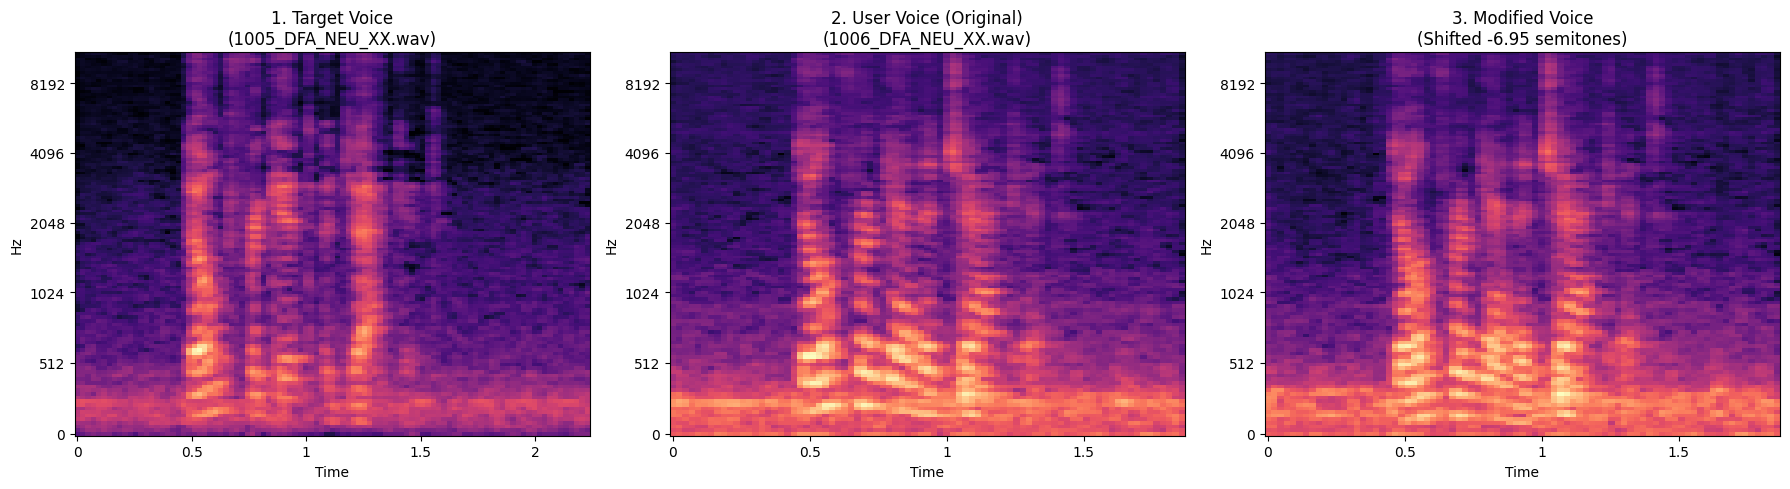

In [11]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

# Convert PyTorch tensors to numpy arrays for Librosa
y_t = w_t.numpy() if hasattr(w_t, 'numpy') else w_t
y_u = w_u.numpy() if hasattr(w_u, 'numpy') else w_u
y_c = y_corr

# Create a figure with 3 subplots side-by-side
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Target Voice
S_t = librosa.feature.melspectrogram(y=y_t, sr=sr_t)
librosa.display.specshow(librosa.power_to_db(S_t, ref=np.max),
                         ax=ax[0], x_axis='time', y_axis='mel')
ax[0].set_title(f"1. Target Voice\n({pair_to_test['target'].name})")

# 2. Plot Original User Voice
S_u = librosa.feature.melspectrogram(y=y_u, sr=sr_u)
librosa.display.specshow(librosa.power_to_db(S_u, ref=np.max),
                         ax=ax[1], x_axis='time', y_axis='mel')
ax[1].set_title(f"2. User Voice (Original)\n({pair_to_test['user'].name})")

# 3. Plot Corrected User Voice
S_c = librosa.feature.melspectrogram(y=y_c, sr=sr_u)
librosa.display.specshow(librosa.power_to_db(S_c, ref=np.max),
                         ax=ax[2], x_axis='time', y_axis='mel')
ax[2].set_title(f"3. Modified Voice\n(Shifted {s_shift:.2f} semitones)")

plt.tight_layout()
plt.show()

Generating academic performance figure...


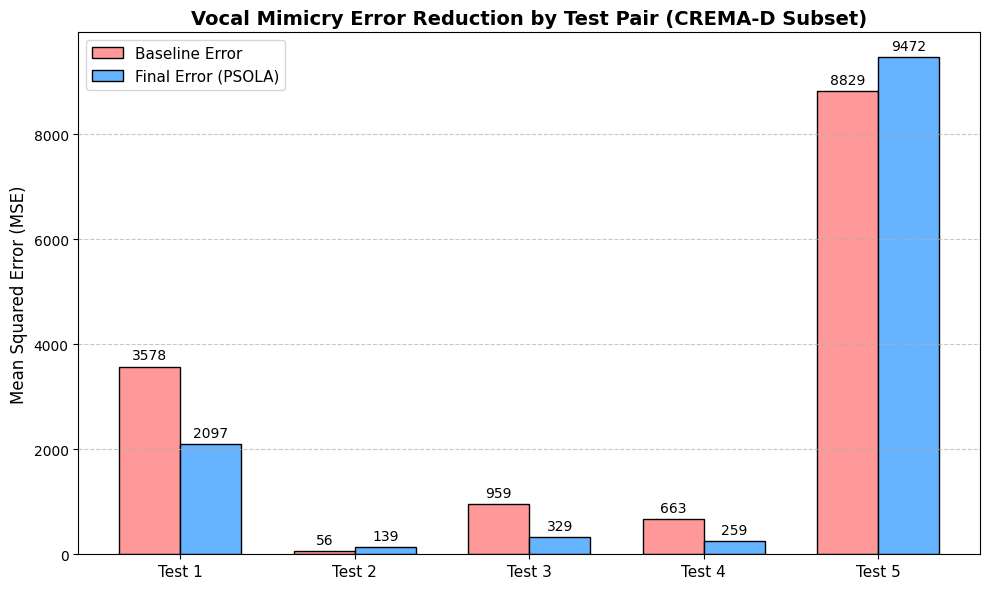

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Check if the table exists
if 'df_summary' in locals():
    print("Generating academic performance figure...")

    # 1. Prepare the data
    labels = df_summary['Pair']
    baseline_mse = df_summary['Baseline MSE'].fillna(0) # Temporarily treat NaN as 0 for drawing
    final_mse = df_summary['Final MSE'].fillna(0)

    # 2. Set up the plot dimensions and bar widths
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    # 3. Plot Baseline vs Final side-by-side
    rects1 = ax.bar(x - width/2, baseline_mse, width, label='Baseline Error', color='#ff9999', edgecolor='black')
    rects2 = ax.bar(x + width/2, final_mse, width, label='Final Error (PSOLA)', color='#66b3ff', edgecolor='black')

    # 4. Add formatting, labels, and titles
    ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
    ax.set_title('Vocal Mimicry Error Reduction by Test Pair (CREMA-D Subset)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend(fontsize=11)

    # 5. Labeling Function
    def attach_smart_labels(rects, original_data):
        for rect, val in zip(rects, original_data):
            height = rect.get_height()
            label_text = 'NaN' if pd.isna(val) else f'{val:.0f}'

            ax.annotate(label_text,
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

    attach_smart_labels(rects1, df_summary['Baseline MSE'])
    attach_smart_labels(rects2, df_summary['Final MSE'])

    # 6. Add a subtle grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.tight_layout()
    plt.show()

else:
    print("⚠️ Error: I couldn't find the 'df_summary' table. Make sure you run the Batch Processing cell first!")